In [81]:
# Ячейка 1: Импорты и настройка
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
# Ячейка 2: Загрузка данных и чистка
df = pd.read_csv("experiments_results.csv")

def clean_model_name(name):
    if name.startswith('ollama:'):
        model = name.split(':', 1)[1]
        if 'llama' in model:
            return 'Llama 3.1 8B'
        elif 'mistral' in model:
            return 'Mistral 7B'
        elif 'qwen' in model:
            return 'Qwen 2.5 7B'
        elif 'deepseek' in model:
            return 'DeepSeek R1 8B'
        elif 'gemma2' in model:
            return 'Gemma 2 9B'
        else:
            return model
    elif name.startswith('gemini:'):
        return 'Gemini 3.1 Flash Lite'
    elif name == 'stub':
        return 'Stub (baseline)'
    elif name == 'openrouter:openai/gpt-oss-120b:free':
        return 'GPT-OSS 120B'
    else:
        return name

df['model'] = df['llm'].apply(clean_model_name)
df.set_index('model', inplace=True)
df

,llm,planner,runs,avg_steps,avg_unique,dead_ends,unreachable,reached,diversity,avg_similarity,avg_rejections,fallback_rate,avg_gen_time,consistency,top_errors
model,,,,,,,,,,,,,,,
Stub (baseline),stub,dqn,30,7.00,7.00,0.0,0.0,30,0.228798,0.194011,0.000000,0.0,0.000059,0.0,[]
Llama 3.1 8B,ollama:llama3.1:8b,dqn,20,6.80,6.80,0.0,0.0,18,0.805287,0.618122,0.086207,0.0,42.102869,0.0,"[('Invalid JSON', 6), (""player_option 1 has in..."
Mistral 7B,ollama:mistral:7b,dqn,20,7.20,7.20,0.0,0.0,16,0.809250,0.621808,0.072581,0.0,56.548616,0.0,"[(""player_option 0 missing 'effect' (required ..."
Gemini 3.1 Flash Lite,gemini:gemini-3.1-flash-lite-preview,dqn,50,7.00,7.00,0.0,0.0,50,0.809219,0.495347,0.000000,0.0,13.461250,0.0,[]
Qwen 2.5 7B,ollama:qwen2.5:7b,dqn,20,5.55,5.55,0.0,0.0,19,0.816767,0.505807,0.032967,0.0,54.636476,0.0,"[(""player_option 2 has invalid effect 'none'. ..."
Gemma 2 9B,ollama:gemma2:9b,dqn,20,8.65,8.65,0.0,0.0,17,0.843232,0.630199,0.326797,0.0,83.115238,0.0,"[('Invalid JSON', 37), ('Dialogue 1 missing te..."
GPT-OSS 120B,openrouter:openai/gpt-oss-120b:free,dqn,6,7.00,7.00,0.0,0.0,6,0.784521,0.523736,0.000000,0.0,17.371053,0.0,[]


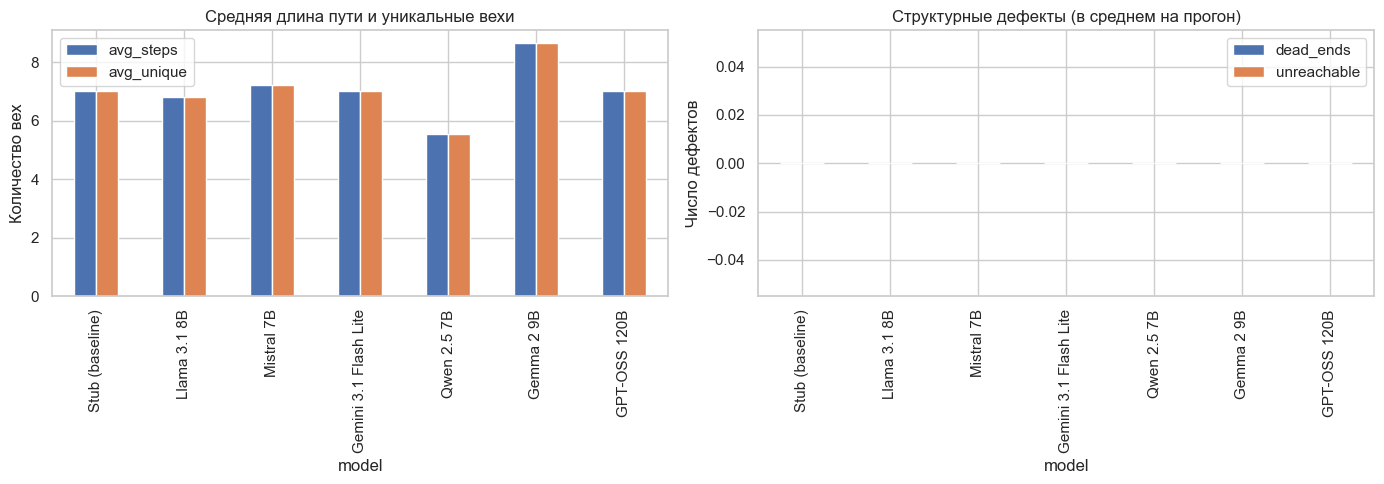

In [83]:
# Ячейка 3: Структурные метрики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[['avg_steps', 'avg_unique']].plot(kind='bar', ax=axes[0], title='Средняя длина пути и уникальные вехи')
axes[0].set_ylabel('Количество вех')

df[['dead_ends', 'unreachable']].plot(kind='bar', ax=axes[1], title='Структурные дефекты (в среднем на прогон)')
axes[1].set_ylabel('Число дефектов')
plt.tight_layout()
plt.show()

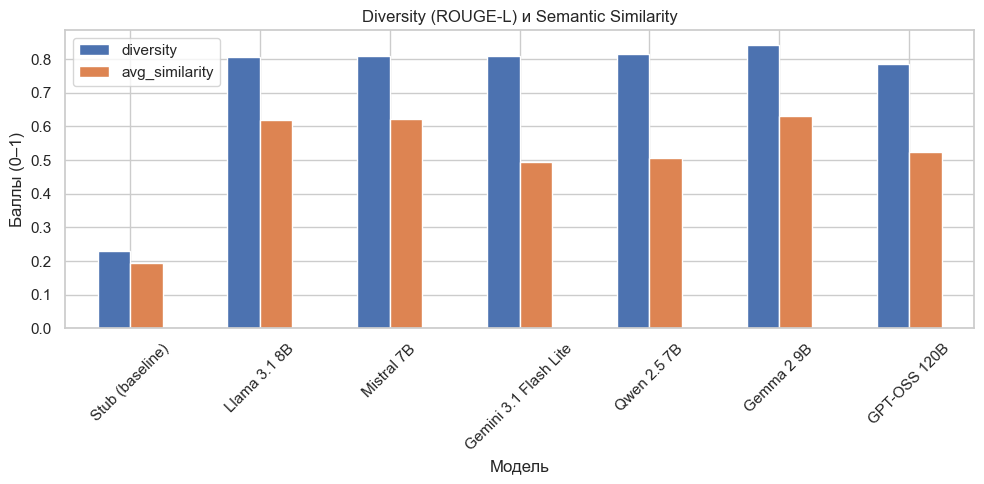

In [84]:
# Ячейка 4: Качество генерации – Diversity и Semantic Similarity
fig, ax = plt.subplots(figsize=(10, 5))
df[['diversity', 'avg_similarity']].plot(kind='bar', ax=ax, title='Diversity (ROUGE-L) и Semantic Similarity')
ax.set_ylabel('Баллы (0–1)')
ax.set_xlabel('Модель')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

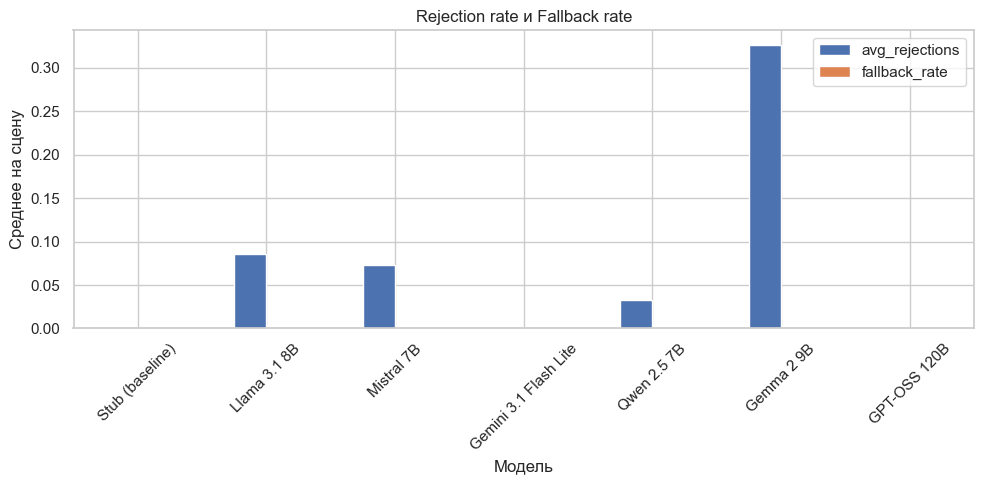

In [85]:
# Ячейка 5: Работа валидатора – Rejections и Fallback rate
fig, ax = plt.subplots(figsize=(10, 5))
df[['avg_rejections', 'fallback_rate']].plot(kind='bar', ax=ax, title='Rejection rate и Fallback rate')
ax.set_ylabel('Среднее на сцену')
ax.set_xlabel('Модель')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

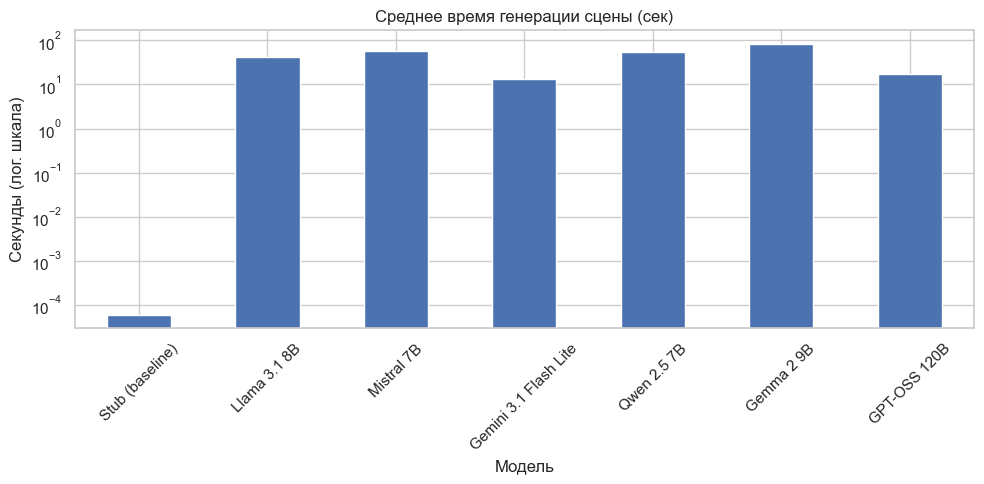

In [86]:
# Ячейка 6: Время генерации (логарифмическая шкала)
fig, ax = plt.subplots(figsize=(10, 5))
df['avg_gen_time'].plot(kind='bar', ax=ax, title='Среднее время генерации сцены (сек)', logy=True)
ax.set_ylabel('Секунды (лог. шкала)')
ax.set_xlabel('Модель')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

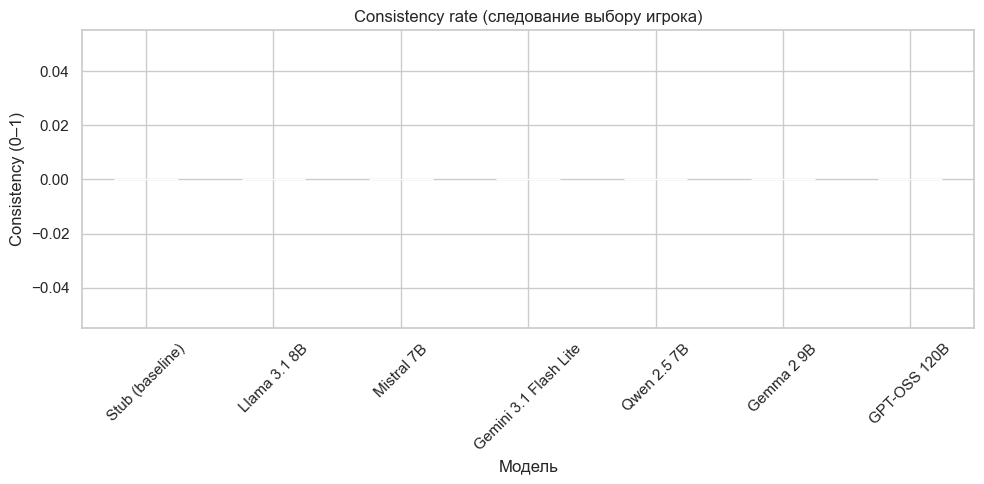

In [87]:
# Ячейка 7: Адаптивность – Consistency rate
fig, ax = plt.subplots(figsize=(10, 5))
df['consistency'].plot(kind='bar', ax=ax, title='Consistency rate (следование выбору игрока)')
ax.set_ylabel('Consistency (0–1)')
ax.set_xlabel('Модель')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Ячейка 8: Ошибки валидатора
if 'top_errors' in df.columns:
    print("Топ ошибок валидатора по моделям:")
    for model in df.index:
        print(f"\n{model}:")
        print(df.loc[model, 'top_errors'])

Топ ошибок валидатора по моделям:

Stub (baseline):
[]

Llama 3.1 8B:
[('Invalid JSON', 6), ("player_option 1 has invalid effect 'none'. Valid", 3), ('Dialogue 1 missing text field', 1)]

Mistral 7B:
[("player_option 0 missing 'effect' (required because narrative_effects is not empty)", 3), ("player_option 0 has invalid effect 'pay_gold'. Valid", 2), ('Invalid JSON', 2)]

Gemini 3.1 Flash Lite:
[]

Qwen 2.5 7B:
[("player_option 2 has invalid effect 'none'. Valid", 1), ('Invalid JSON', 1), ("player_option 1 has invalid effect 'none'. Valid", 1)]

Gemma 2 9B:
[('Invalid JSON', 37), ('Dialogue 1 missing text field', 7), ('Dialogue 0 missing text field', 6)]

GPT-OSS 120B:
[]


In [ ]:
# Ячейка 9: Сводная таблица
summary = df[['runs', 'avg_steps', 'avg_unique', 'diversity', 'avg_similarity',
              'avg_rejections', 'fallback_rate', 'avg_gen_time', 'consistency']].copy()
summary

,runs,avg_steps,avg_unique,diversity,avg_similarity,avg_rejections,fallback_rate,avg_gen_time,consistency
model,,,,,,,,,
Stub (baseline),30,7.00,7.00,0.228798,0.194011,0.000000,0.0,0.000059,0.0
Llama 3.1 8B,20,6.80,6.80,0.805287,0.618122,0.086207,0.0,42.102869,0.0
Mistral 7B,20,7.20,7.20,0.809250,0.621808,0.072581,0.0,56.548616,0.0
Gemini 3.1 Flash Lite,50,7.00,7.00,0.809219,0.495347,0.000000,0.0,13.461250,0.0
Qwen 2.5 7B,20,5.55,5.55,0.816767,0.505807,0.032967,0.0,54.636476,0.0
Gemma 2 9B,20,8.65,8.65,0.843232,0.630199,0.326797,0.0,83.115238,0.0
GPT-OSS 120B,6,7.00,7.00,0.784521,0.523736,0.000000,0.0,17.371053,0.0
